In [61]:
# FERNANDO JOSE MENEZES DA SILVA, ANALISES DE DADOS - APONTI


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [ ]:
raiz = Path(".")
pastas = [
    "dados_brutos" , "dados_tratados" , "notbooks" , "sql" ,
    "relatorios" , "apresentacao" , "logs"
]

for pasta in pastas:
  (raiz / pasta).mkdir(parents= True , exist_ok=True)

print("Pastas verificadas/criadas:")
for pasta in pastas:
  print("-", raiz/pasta)


Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notbooks
- sql
- relatorios
- apresentacao
- logs


In [28]:
ARQUIVO_BRUTO = Path("dados_brutos/dados_abertos_prf-datatran2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

SEPARADOR = ","
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

In [14]:
ARQUIVO_BRUTO = Path("dados_brutos/dados_abertos_prf-datatran2025.csv")
print(f"Novo caminho do arquivo bruto: {ARQUIVO_BRUTO}")

Novo caminho do arquivo bruto: dados_brutos/dados_abertos_prf-datatran2025.csv


In [16]:
import os

os.makedirs("/content/dados_brutos", exist_ok=True)

print("Pasta criada:", os.path.exists("/content/dados_brutos"))

Pasta criada: True


In [20]:
from google.colab import files
import shutil
import os

arquivos = files.upload()

for arquivo in arquivos.keys():
    shutil.move(
        arquivo,
        os.path.join("/content/dados_brutos", arquivo)
    )

print("Upload concluído!")

Saving dados_abertos_prf-datatran2025 (1) - dados_abertos_prf-datatran2025 (1).csv to dados_abertos_prf-datatran2025 (1) - dados_abertos_prf-datatran2025 (1).csv
Upload concluído!


In [21]:
import os

print(os.listdir("/content/dados_brutos"))

['dados_abertos_prf-datatran2025 (1) - dados_abertos_prf-datatran2025 (1).csv']


In [22]:
import os

os.rename(
    "/content/dados_brutos/dados_abertos_prf-datatran2025 (1) - dados_abertos_prf-datatran2025 (1).csv",
    "/content/dados_brutos/dados_abertos_prf-datatran2025.csv"
)

In [23]:
os.listdir("/content/dados_brutos")

['dados_abertos_prf-datatran2025.csv']

In [24]:
import os

ARQUIVO_BRUTO = "dados_brutos/dados_abertos_prf-datatran2025.csv"

print("Arquivo existe?", os.path.exists(ARQUIVO_BRUTO))

Arquivo existe? True


In [30]:
df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head(5)

Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,ReaÃ§Ã£o tardia ou ineficiente do condutor,Tombamento,Com VÃ­timas Feridas,Pleno dia,Decrescente,CÃ©u Claro,MÃºltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,ColisÃ£o frontal,NaN,Pleno dia,Crescente,CÃ©u Claro,Simples,Reta,NÃ£o,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,ReaÃ§Ã£o tardia ou ineficiente do condutor,ColisÃ£o traseira,Com VÃ­timas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,ReaÃ§Ã£o tardia ou ineficiente do condutor,SaÃ­da de leito carroÃ§Ã¡vel,Com VÃ­timas Feridas,Pleno dia,Crescente,CÃ©u Claro,Dupla,Reta,NÃ£o,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade IncompatÃ­vel,ColisÃ£o frontal,Com VÃ­timas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,NÃ£o,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [32]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    while "__" in nome:
       nome = nome.replace("__", "_")
    return nome.strip("_")
df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Compatibilização de grafias possíveis
renomear = {"condicao_meteorologica": "condicao_metereologica"}
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})
print(df.columns.tolist())


['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [33]:
#Validando estrutura da base
#Identificando campos faltantes
colunas_esperadas = [
    "data_inversa",
    "dia_semana",
    "horario",
    "uf",
    "br",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "classificacao_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "feridos",
    "veiculos"
     ]
faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)

if faltantes:
   print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")



Colunas faltantes: []


In [34]:
#Executar a conferência e comentar qualquer coluna faltante.
#Dimensões, Primeiras linhas, Amostra aleatoria, Senso inicial do conteudo.
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

display(df.head())
display(df.sample(5, random_state=42))

Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,ReaÃ§Ã£o tardia ou ineficiente do condutor,Tombamento,Com VÃ­timas Feridas,Pleno dia,Decrescente,CÃ©u Claro,MÃºltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,ColisÃ£o frontal,NaN,Pleno dia,Crescente,CÃ©u Claro,Simples,Reta,NÃ£o,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,ReaÃ§Ã£o tardia ou ineficiente do condutor,ColisÃ£o traseira,Com VÃ­timas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,ReaÃ§Ã£o tardia ou ineficiente do condutor,SaÃ­da de leito carroÃ§Ã¡vel,Com VÃ­timas Feridas,Pleno dia,Crescente,CÃ©u Claro,Dupla,Reta,NÃ£o,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade IncompatÃ­vel,ColisÃ£o frontal,Com VÃ­timas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,NÃ£o,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sÃ¡bado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminaÃ§Ã£o vermelha ...,ColisÃ£o transversal,Com VÃ­timas Feridas,Pleno dia,Crescente,Sol,Simples,RotatÃ³ria,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distÃ¢ncia do veÃ­cu...,ColisÃ£o traseira,Sem VÃ­timas,Plena Noite,Decrescente,CÃ©u Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com VÃ­timas Feridas,Plena Noite,Decrescente,CÃ©u Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,ReaÃ§Ã£o tardia ou ineficiente do condutor,Engavetamento,Com VÃ­timas Feridas,Plena Noite,Crescente,CÃ©u Claro,Dupla,Reta,NÃ£o,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com VÃ­timas Feridas,Plena Noite,Decrescente,CÃ©u Claro,Simples,Declive,NÃ£o,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


In [36]:
#Diagnóstico de qualidade dos dados;
#Tipos de dados e memória;
# Tipos inferidos pelo pandas, Uso de memória, Colunas numéricas como texto, Datas ainda como objeto.

df.info(memory_usage="deep")
resumo_tipos = (
    df.dtypes.astype(str) .value_counts() .rename_axis("tipo") .reset_index(name="qtd_colunas") )
display(resumo_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


In [37]:
# Diagnóstico de valores ausentes;
#Quantidade de nulos, Percentual de nulos, Priorizar campos relevantes, Não confundir nulo com zero.

nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)
display(nulos[nulos["qtd_nulos"] > 0])

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


In [38]:
#Cardinalidade das Categorias
#Quantas categorias por campo, Município tende a ser alto, Causa e tipo exigem cuidado, Categorias raras podem distorcer análise.

categoricas = df.select_dtypes(include="object").columns
cardinalidade = (
    df[categoricas].nunique(dropna=True) .sort_values(ascending=False) .reset_index() )
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))

,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [39]:
#Transformações e criação de variáveis derivadas
#Converter colunas numéricas;
#Contagens de vítimas, BR e km, Conversão segura, Nulos podem surgir por erro de formato.

colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves", "feridos_graves", "ilesos", "ignorados", "veiculos"
]

for coluna in colunas_numericas:
  if coluna in df.columns:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [40]:
# Tratar datas e criar variáveis temporais.
#data_inversa para datetime, ano, mês e trimestre, dia da semana numérico, fim de semana.

df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)


display(df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num", "fim_de_semana"]].head())


,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


In [41]:
#Tratar horário e criar turno.
#Extrair hora, Classificar madrugada, manhã, tarde e noite, Tratar horários inválidos, Gerar variável interpretável.

horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

# Tentativa alternativa para arquivos com HH:MM
faltou_hora = df["hora"].isna()
if faltou_hora.any():
  df.loc[faltou_hora, "hora"] = pd.to_datetime(
      horario_limpo[faltou_hora], format="%H:%M", errors="coerce" ).dt.hour

def classificar_turno(hora):
   if pd.isna(hora):
    return "IGNORADO"
   if 0 <= hora <= 5:
     return "MADRUGADA"
   if 6 <= hora <= 11:
     return "MANHA"
   if 12 <= hora <= 17:
     return "TARDE"
   return "NOITE"

df["turno"] = df["hora"].apply(classificar_turno)
display(df[["horario", "hora", "turno"]].head())


,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


In [42]:
# Criar faixa horária
#Blocos de 3 horas, Reduz granularidade, Ajuda em padrões temporais, Útil para modelo explicável.
def criar_faixa_horaria(hora):
  if pd.isna(hora):
     return "IGNORADO"
  inicio = int(hora // 3) * 3
  fim = inicio + 2
  return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())


,count
faixa_horaria,
00h-02h,3959
03h-05h,4948
06h-08h,11517
09h-11h,9342
12h-14h,9678
15h-17h,12624
18h-20h,13473
21h-23h,6988


In [43]:
#Padronizar texto.
#Remover espaços, Maiúsculas, Vazios como nulos, Categorias mais consistentes.

colunas_texto = df.select_dtypes(include="object").columns

for coluna in colunas_texto:
  df[coluna] = (df[coluna].astype("string").str.strip().str.upper())
  df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})
print("Colunas textuais padronizadas:", len(colunas_texto))

Colunas textuais padronizadas: 20


In [44]:
#Tratar nulos categóricos
#Usar IGNORADO em campos explicativos, Evitar perda de linhas, Preservar informação de ausência, Documentar decisão.

categoricas_importantes = [
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia","condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo", "classificacao_acidente", "dia_semana" ]

for coluna in categoricas_importantes:
   if coluna in df.columns:
    df[coluna] = df[coluna].fillna("IGNORADO")

print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))


uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


In [45]:
# Tratar nulos numéricos de contagem
#Contagens de vítimas, Zero como hipótese operacional, Atenção à semântica da coluna, Registrar decisão.

contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas", "veiculos"]

for coluna in contagens_vitimas:
  if coluna in df.columns:
    df[coluna] = df[coluna].fillna(0)

print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())


mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


In [47]:
#Variável-alvo e indicadores de gravidade
#Criar variável-alvo acidente_fatal;
# 1 quando mortos \>= 1, 0 quando mortos = 0, Centro do problema binário, Base para análises posteriores.

df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)
validacao_alvo = df["acidente_fatal"].value_counts(dropna=False).rename_axis("acidente_fatal").reset_index(name="qtd")
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100
display(validacao_alvo)


,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


In [48]:
#Validar logicamente o alvo
#Testar regra, Detectar inversões, Detectar nulos indevidos, Usar assert.

violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) | ((df["mortos"] == 0) & (df["acidente_fatal"] != 0)) ]
print("Violações da regra do alvo:", len(violacoes))
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."


Violações da regra do alvo: 0


In [49]:
# Criar indicadores de gravidade
#total_vitimas, acidente_grave, indice_gravidade, Uso: análise e Power BI.

df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where(
     (df["mortos"] >= 1) | (df["feridos_graves"] >= 1),1,0 )
df["indice_gravidade"] = (
     df["mortos"] * 3
     + df["feridos_graves"] * 2
     + df["feridos_leves"] )
display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade"]].head())


,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


In [50]:
# Criar BR formatada e chave de localidade
#BR-000, BR ignorada, UF + município + BR, Facilita filtros e agrupamentos.

def formatar_br(valor):
  if pd.isna(valor) or valor == 0:
    return "BR-IGNORADA"
  return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)

df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str) )

display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())

,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


In [51]:
# Checagens rápidas após transformação
#Linhas e colunas, Quantidade de fatais, Taxa de fatalidade, Totais de mortos e feridos.

checagens = {
     "linhas": len(df),
      "colunas": df.shape[1],
     "acidentes_fatais": int(df["acidente_fatal"].sum()),
     "taxa_fatalidade": float(df["acidente_fatal"].mean()),
     "total_mortos": int(df["mortos"].sum()),
     "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}
checagens

{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

In [52]:
#Ranking rápido de categorias
#Causas mais frequentes, Tipos mais frequentes, Conferência de categorias, Preparação para EDA.

def ranking_categoria(base, coluna, n=10):
  return (
      base[coluna].value_counts(dropna=False).head(n).rename_axis(coluna).reset_index(name="qtd") )
display(ranking_categoria(df, "causa_acidente", 10))
display(ranking_categoria(df, "tipo_acidente", 10))

,causa_acidente,qtd
0,AUSÃªNCIA DE REAÃ§Ã£O DO CONDUTOR,11469
1,REAÃ§Ã£O TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÃ§A DOS OUT...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÃ¢NCIA DO VEÃ­CU...,4413
4,VELOCIDADE INCOMPATÃ­VEL,4088
5,MANOBRA DE MUDANÃ§A DE FAIXA,4016
6,INGESTÃ£O DE Ã¡LCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÃ¢NICAS OU ELÃ©TRICAS,3385
8,TRANSITAR NA CONTRAMÃ£O,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃ£O TRASEIRA,14360
1,SAÃ­DA DE LEITO CARROÃ§Ã¡VEL,10209
2,COLISÃ£O TRANSVERSAL,9306
3,COLISÃ£O LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃ£O COM OBJETO,5109
6,COLISÃ£O FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÃ­CULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃ£O LATERAL SENTIDO OPOSTO,2152


In [53]:
#Taxa fatal por categoria
#Proporção, não apenas frequência, Filtro por mínimo de registros, Evitar subgrupos minúsculos, Preparação para análise bivariada.

def taxa_fatal_por_categoria(base, coluna, min_registros=30):
  tab = base.groupby(coluna).agg(
     qtd_acidentes=("acidente_fatal", "size"),
     qtd_fatais=("acidente_fatal", "sum"),
     taxa_fatal=("acidente_fatal", "mean")
  ).reset_index()
  tab = tab[tab["qtd_acidentes"] >= min_registros]
  return tab.sort_values("taxa_fatal", ascending=False)

display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))


,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃ£O FRONTAL,4739,1396,0.294577
6,COLISÃ£O LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÃ­PICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÃ­DA DE LEITO CARROÃ§Ã¡VEL,10209,605,0.059261
3,COLISÃ£O COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃ£O TRANSVERSAL,9306,427,0.045884
8,COLISÃ£O TRASEIRA,14360,619,0.043106


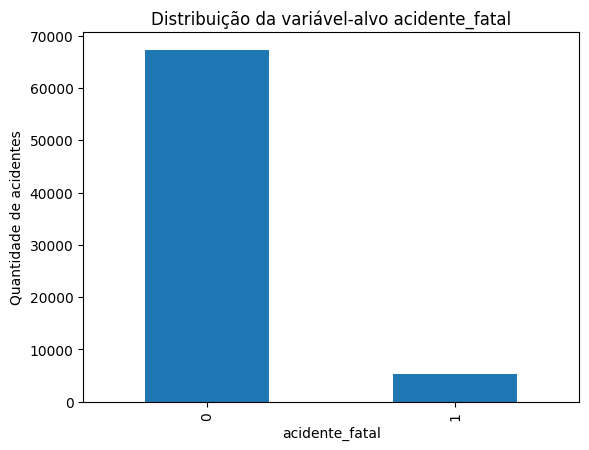

In [54]:
#Gráfico simples de conferência
#Distribuição do alvo, Visualização rápida, Não substitui EDA, Ajuda a detectar desequilíbrio.

ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável-alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")
plt.show()


In [55]:
#Construção das duas bases (analítica e modelável)
# Gerar base analítica completa;
#Cópia da base tratada, Preserva variáveis descritivas, Inclui indicadores de gravidade, Será usada nos módulos 5 e 6.

base_analitica = df.copy()
print("Base analítica:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())


Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


In [56]:
#Conceito de base modelável
#Usada na árvore de decisão, Apenas variáveis explicativas, Inclui acidente_fatal como alvo, Exclui variáveis derivadas do desfecho.

#Selecionar variáveis modeláveis;
#UF, BR, município, Tempo e turno, Causa, tipo, pista, clima e traçado, Alvo acidente_fatal.

variaveis_modelaveis = [
     "uf", "br_formatada", "municipio", "mes", "trimestre",
     "dia_semana", "dia_semana_num", "fim_de_semana",
     "hora", "faixa_horaria", "turno", "fase_dia",
     "causa_acidente", "tipo_acidente", "condicao_metereologica",
      "tipo_pista", "tracado_via", "uso_solo",
      "acidente_fatal" ]

variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]
base_modelavel = df[variaveis_modelaveis].copy()


print("Base modelável:", base_modelavel.shape)

Base modelável: (72529, 19)


In [57]:
#Verificar data leakage;
#mortos fora da modelável, feridos fora da modelável, total_vitimas fora da modelável, indice_gravidade fora da modelável.

variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "acidente_grave",
    "classificacao_acidente" ]

def verificar_data_leakage(base, proibidas):
   presentes = [c for c in proibidas if c in base.columns]
   if presentes:
      raise ValueError(f"Data leakage detectado: {presentes}")
   return "OK — nenhuma variável proibida encontrada."

verificar_data_leakage(base_modelavel, variaveis_proibidas)


'OK — nenhuma variável proibida encontrada.'

In [58]:
#Tratamento final de nulos na base modelável;
#Categóricas: IGNORADO, Numéricas: -1 quando necessário, Alvo preservado, Evitar erro na modelagem.

for coluna in base_modelavel.columns:
   if coluna == "acidente_fatal":
     continue
   if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
    base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
   else:
      base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

print(base_modelavel.isna().sum().sort_values(ascending=False).head())

uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


In [59]:
# Exportar bases tratadas
#CSV em dados_tratados, Separador ; , utf-8-sig, Não sobrescrever dados brutos.

base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados:
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv


In [60]:
#Reabrir arquivos exportados;
#Validação pós-exportação, Conferir dimensões, Garantir legibilidade, Detectar erro de encoding.

valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)
assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)


Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)


In [62]:
#Gerar dicionário das variáveis criadas;
#Descrição das novas variáveis, Uso previsto, Apoio à avaliação, Apoio aos módulos seguintes.

linhas_dic = [
     {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso": "alvo"},
     {"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
     {"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves", "uso": "analise/dashboard"},
     {"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso": "analise/modelagem"},
     {"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso": "analise/dashboard"}, ]

dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
display(dicionario)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


In [63]:
#Registrar decisões de tratamento;
#Data da geração, Regras adotadas, Arquivos gerados, Justificativa metodológica.

texto_decisoes = f"""
# Decisões de tratamento — Módulo 4
Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
print(ARQUIVO_DECISOES)

logs/decisoes_tratamento_modulo4.md


In [64]:
#Criar README do projeto;
#Objetivo, Variável-alvo, Bases geradas, Observação sobre data leakage.

readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de decisão explicável.

## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.


## Observação metodológica
A base modelável exclui mortos, feridos, total_vitimas, indice_gravidade e variáveis diretamente derivadas do desfecho.
"""

ARQUIVO_README.write_text(readme, encoding="utf-8")
print("README criado:", ARQUIVO_README)

README criado: README.md


In [65]:
#Resumo final da preparação
#Dimensões das bases, Taxa global de fatalidade, Conferência final, Evidência para avaliação.

resumo_final = pd.DataFrame([
     {"item": "linhas_base_analitica", "valor": len(base_analitica)},
     {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
     {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
     {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
     {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()}, ])

display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833
